# TC3002B Fact-Checking Model — Implementación y Evaluación de Modelos
Angel Mauricio Ramírez Herrera | A01710158

---

## Objetivo

Implementar y comparar múltiples modelos de clasificación sobre el dataset **SCVD-11K**, desde un baseline simple hasta modelos de Deep Learning, para identificar cuál ofrece el mejor desempeño en la tarea de **Fact-Checking** con tres clases:

- **Supported** → Afirmación respaldada por consenso científico.
- **Refuted** → Afirmación contradice evidencia científica.
- **Not Enough Evidence** → No existe evidencia suficiente.

---

## Modelos implementados

| # | Modelo | Tipo |
|---|--------|------|
| 1 | Dummy Classifier (Most Frequent) | Baseline |
| 2 | Logistic Regression + TF-IDF | ML Clásico |
| 3 | Naive Bayes + TF-IDF | ML Clásico |
| 4 | SVM Lineal + TF-IDF | ML Clásico |
| 5 | Random Forest + TF-IDF | ML Clásico |
| 6 | Gradient Boosting + TF-IDF | ML Clásico |
| 7 | LSTM con Embedding aprendido | Deep Learning |
| 8 | BiLSTM con Embedding aprendido | Deep Learning |
| 9 | CNN + BiGRU + GloVe | Deep Learning |

## 1. Importación de dependencias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
warnings.filterwarnings('ignore')

# ML Clásico
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout,
    Conv1D, MaxPooling1D, GRU
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import kagglehub

print('TensorFlow version:', tf.__version__)
print('GPU disponible:', len(tf.config.list_physical_devices('GPU')) > 0)

2026-04-19 23:22:36.271962: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776640956.456024      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776640956.511226      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776640956.979310      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776640956.979351      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776640956.979354      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU disponible: True


## 2. Carga y preprocesamiento del dataset SCVD-11K

In [2]:
def get_dir_size(path):
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total += os.path.getsize(fp)
    return total

path = kagglehub.dataset_download('sudhanshuyadav09/scientific-fact-check-classification-dataset')
print('Path to dataset files:', path)
size_mb = get_dir_size(path) / (1024 * 1024)
print(f'Tamaño total de los archivos: {size_mb:.2f} MB')

Path to dataset files: /kaggle/input/datasets/sudhanshuyadav09/scientific-fact-check-classification-dataset
Tamaño total de los archivos: 0.84 MB


In [3]:
files = os.listdir(path)
print(files)

train_file = [f for f in files if f.endswith('.csv')][1]
test_file  = [f for f in files if f.endswith('.csv')][0]

df_train = pd.read_csv(os.path.join(path, train_file), on_bad_lines='skip', low_memory=False)
df_test  = pd.read_csv(os.path.join(path, test_file),  on_bad_lines='skip', low_memory=False)

print(f'Train shape: {df_train.shape}')
print(f'Test shape:  {df_test.shape}')

['scientific_claim_test.csv', 'scientific_claim_train.csv']
Train shape: (10000, 2)
Test shape:  (1000, 2)


Merged shape: (11000, 2)
Distribución de clases:
label
Supported              3668
Not Enough Evidence    3666
Refuted                3666
Name: count, dtype: int64


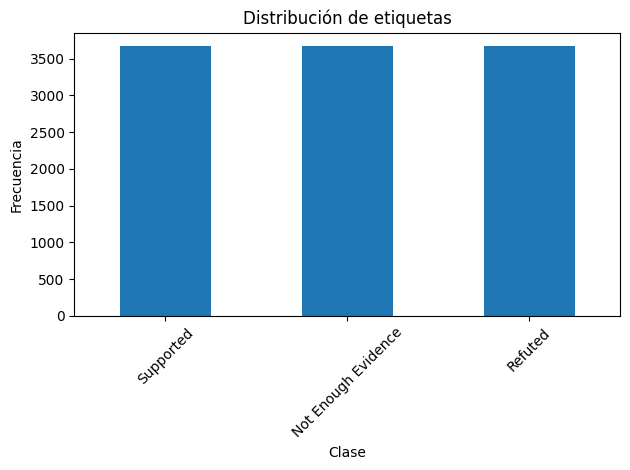

In [4]:
df_merged = pd.concat([df_train, df_test], ignore_index=True)
print(f'Merged shape: {df_merged.shape}')
print(f'Distribución de clases:')
print(df_merged['label'].value_counts())

df_merged['label'].value_counts().plot(kind='bar')
plt.title('Distribución de etiquetas')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.1 Limpieza de texto

Se aplica el mismo pipeline de limpieza del modelo base:
1. Eliminación de IDs entre paréntesis
2. Eliminación de corchetes y su contenido
3. Reemplazo de saltos de línea
4. Solo caracteres alfabéticos
5. Normalización de espacios
6. Conversión a minúsculas

In [5]:
def clean_text(series):
    return (
        series
        .str.replace(r'\(Statement ID \d+\)$', '', regex=True)
        .str.replace(r'\[.*?\]', '', regex=True)
        .str.replace(r'\n+', ' ', regex=True)
        .str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
        .str.lower()
    )

df_merged['statement_clean'] = clean_text(df_merged['statement'])

print('Ejemplos de texto limpio:')
for i in range(3):
    print(f'  Original: {df_merged["statement"].iloc[i][:80]}')
    print(f'  Limpio:   {df_merged["statement_clean"].iloc[i][:80]}')
    print()

Ejemplos de texto limpio:
  Original: Dark matter might interact weakly with normal matter. (Statement ID 8836)
  Limpio:   dark matter might interact weakly with normal matter

  Original: The Earth is flat. (Statement ID 5654)
  Limpio:   the earth is flat

  Original: Climate change is a hoax created by scientists. (Statement ID 6171)
  Limpio:   climate change is a hoax created by scientists



### 2.2 División train/val/test y encoding de etiquetas

In [6]:
train_clean = df_merged.iloc[:len(df_train)].copy()
test_clean  = df_merged.iloc[len(df_train):].copy()

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    train_clean['statement_clean'],
    train_clean['label'],
    test_size=0.2,
    random_state=42,
    stratify=train_clean['label']
)

X_test_raw = test_clean['statement_clean']
y_test_raw = test_clean['label']

le = LabelEncoder()
le.fit(df_merged['label'])

y_train = le.transform(y_train_raw)
y_val   = le.transform(y_val_raw)
y_test  = le.transform(y_test_raw)

print(f'Clases: {list(le.classes_)}')
print(f'Train:  {len(X_train_raw)} muestras')
print(f'Val:    {len(X_val_raw)} muestras')
print(f'Test:   {len(X_test_raw)} muestras')

Clases: ['Not Enough Evidence', 'Refuted', 'Supported']
Train:  8000 muestras
Val:    2000 muestras
Test:   1000 muestras


## 3. Funciones de evaluación

**Métricas seleccionadas** (Sokolova & Lapalme, 2009):

| Métrica | Justificación |
|---------|---------------|
| **Accuracy** | Válida dado que el dataset está **balanceado**. |
| **F1 Macro** | Penaliza igual el error en todas las clases. Recomendada en NLP multiclase. |
| **F1 Weighted** | Complementa al F1 Macro considerando soporte de cada clase. |

In [7]:
results = {}

def evaluate_model(name, y_true, y_pred, training_time=None):
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro')
    f1_wei = f1_score(y_true, y_pred, average='weighted')

    results[name] = {
        'Accuracy':          round(acc, 4),
        'F1 Macro':          round(f1_mac, 4),
        'F1 Weighted':       round(f1_wei, 4),
        'Training Time (s)': round(training_time, 2) if training_time else None
    }

    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Accuracy:     {acc:.4f}')
    print(f'  F1 Macro:     {f1_mac:.4f}')
    print(f'  F1 Weighted:  {f1_wei:.4f}')
    if training_time:
        print(f'  Training time: {training_time:.2f}s')
    print()
    print(classification_report(y_true, y_pred, target_names=le.classes_))


def plot_confusion_matrix(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.title(f'Matriz de Confusión — {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Etiqueta Real')
    plt.tight_layout()
    plt.show()

## 4. Modelo 1 — Baseline: Dummy Classifier

Predice siempre la clase más frecuente. Establece el **piso mínimo** de rendimiento.
Con tres clases balanceadas, accuracy esperado ≈ 33%.


  1. Dummy Classifier
  Accuracy:     0.3330
  F1 Macro:     0.1665
  F1 Weighted:  0.1664
  Training time: 0.00s

                     precision    recall  f1-score   support

Not Enough Evidence       0.00      0.00      0.00       333
            Refuted       0.33      1.00      0.50       333
          Supported       0.00      0.00      0.00       334

           accuracy                           0.33      1000
          macro avg       0.11      0.33      0.17      1000
       weighted avg       0.11      0.33      0.17      1000



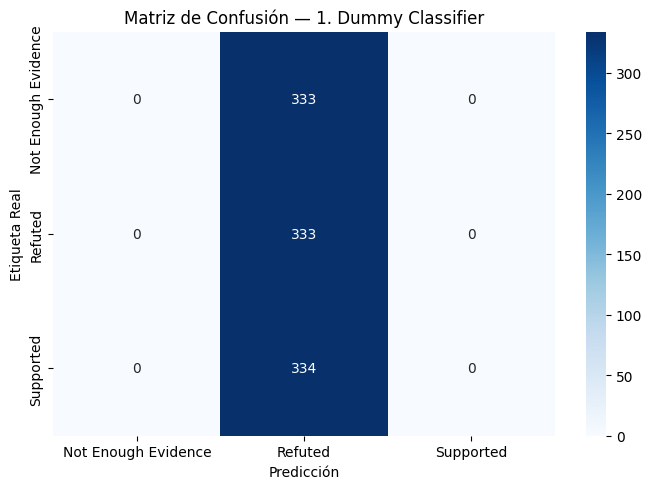

In [8]:
t0 = time.time()
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_raw, y_train)
y_pred_dummy = dummy.predict(X_test_raw)
t1 = time.time()

evaluate_model('1. Dummy Classifier', y_test, y_pred_dummy, t1 - t0)
plot_confusion_matrix('1. Dummy Classifier', y_test, y_pred_dummy)

## 5. Modelos ML Clásicos con TF-IDF

**TF-IDF** vectoriza el texto capturando la importancia de cada término.

**Configuración:** `max_features=20000`, `ngram_range=(1,2)`, `sublinear_tf=True`

### 5.1 Modelo 2 — Logistic Regression + TF-IDF


  2. Logistic Regression + TF-IDF
  Accuracy:     1.0000
  F1 Macro:     1.0000
  F1 Weighted:  1.0000
  Training time: 0.16s

                     precision    recall  f1-score   support

Not Enough Evidence       1.00      1.00      1.00       333
            Refuted       1.00      1.00      1.00       333
          Supported       1.00      1.00      1.00       334

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



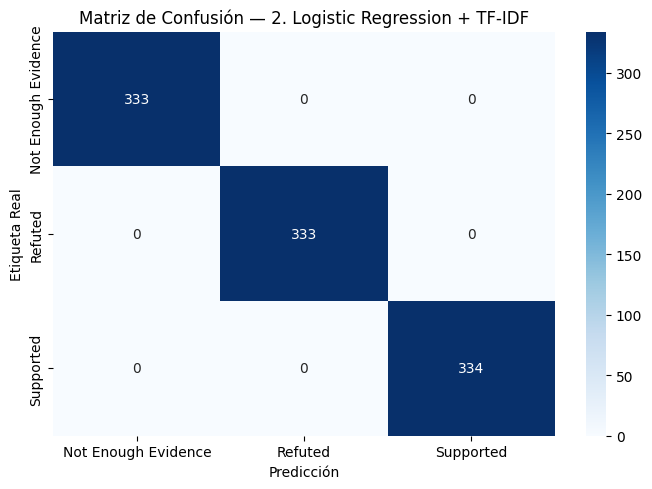

In [9]:
t0 = time.time()
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])
lr_pipeline.fit(X_train_raw, y_train)
y_pred_lr = lr_pipeline.predict(X_test_raw)
t1 = time.time()

evaluate_model('2. Logistic Regression + TF-IDF', y_test, y_pred_lr, t1 - t0)
plot_confusion_matrix('2. Logistic Regression + TF-IDF', y_test, y_pred_lr)

### 5.2 Modelo 3 — Naive Bayes + TF-IDF


  3. Naive Bayes + TF-IDF
  Accuracy:     1.0000
  F1 Macro:     1.0000
  F1 Weighted:  1.0000
  Training time: 0.10s

                     precision    recall  f1-score   support

Not Enough Evidence       1.00      1.00      1.00       333
            Refuted       1.00      1.00      1.00       333
          Supported       1.00      1.00      1.00       334

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



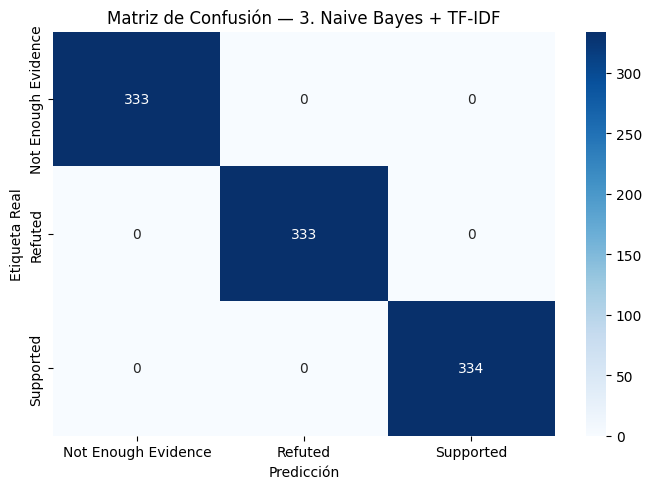

In [10]:
t0 = time.time()
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   MultinomialNB(alpha=0.1))
])
nb_pipeline.fit(X_train_raw, y_train)
y_pred_nb = nb_pipeline.predict(X_test_raw)
t1 = time.time()

evaluate_model('3. Naive Bayes + TF-IDF', y_test, y_pred_nb, t1 - t0)
plot_confusion_matrix('3. Naive Bayes + TF-IDF', y_test, y_pred_nb)

### 5.3 Modelo 4 — SVM Lineal + TF-IDF


  4. SVM Lineal + TF-IDF
  Accuracy:     1.0000
  F1 Macro:     1.0000
  F1 Weighted:  1.0000
  Training time: 0.35s

                     precision    recall  f1-score   support

Not Enough Evidence       1.00      1.00      1.00       333
            Refuted       1.00      1.00      1.00       333
          Supported       1.00      1.00      1.00       334

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



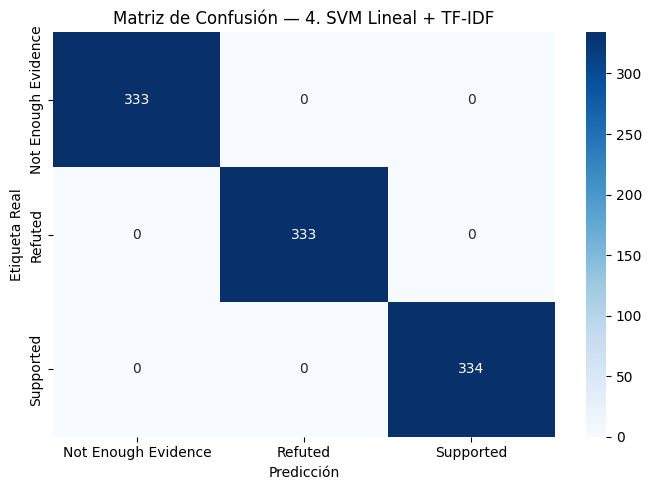

In [11]:
t0 = time.time()
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LinearSVC(C=1.0, max_iter=2000, random_state=42))
])
svm_pipeline.fit(X_train_raw, y_train)
y_pred_svm = svm_pipeline.predict(X_test_raw)
t1 = time.time()

evaluate_model('4. SVM Lineal + TF-IDF', y_test, y_pred_svm, t1 - t0)
plot_confusion_matrix('4. SVM Lineal + TF-IDF', y_test, y_pred_svm)

### 5.4 Modelo 5 — Random Forest + TF-IDF


  5. Random Forest + TF-IDF
  Accuracy:     1.0000
  F1 Macro:     1.0000
  F1 Weighted:  1.0000
  Training time: 0.71s

                     precision    recall  f1-score   support

Not Enough Evidence       1.00      1.00      1.00       333
            Refuted       1.00      1.00      1.00       333
          Supported       1.00      1.00      1.00       334

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



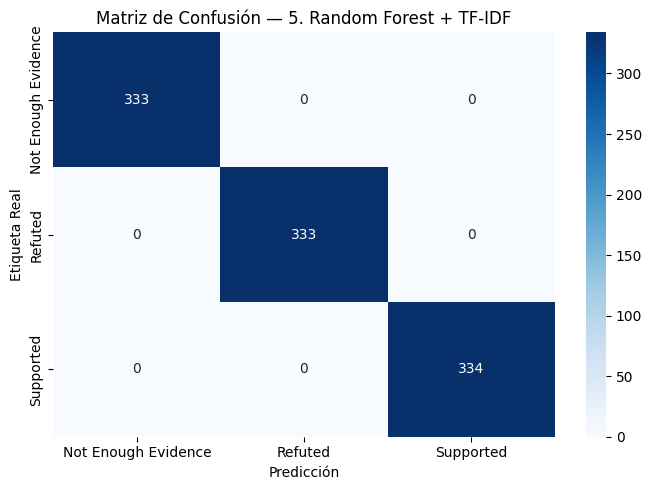

In [12]:
t0 = time.time()
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))
])
rf_pipeline.fit(X_train_raw, y_train)
y_pred_rf = rf_pipeline.predict(X_test_raw)
t1 = time.time()

evaluate_model('5. Random Forest + TF-IDF', y_test, y_pred_rf, t1 - t0)
plot_confusion_matrix('5. Random Forest + TF-IDF', y_test, y_pred_rf)

### 5.5 Modelo 6 — Gradient Boosting + TF-IDF


  6. Gradient Boosting + TF-IDF
  Accuracy:     1.0000
  F1 Macro:     1.0000
  F1 Weighted:  1.0000
  Training time: 3.42s

                     precision    recall  f1-score   support

Not Enough Evidence       1.00      1.00      1.00       333
            Refuted       1.00      1.00      1.00       333
          Supported       1.00      1.00      1.00       334

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



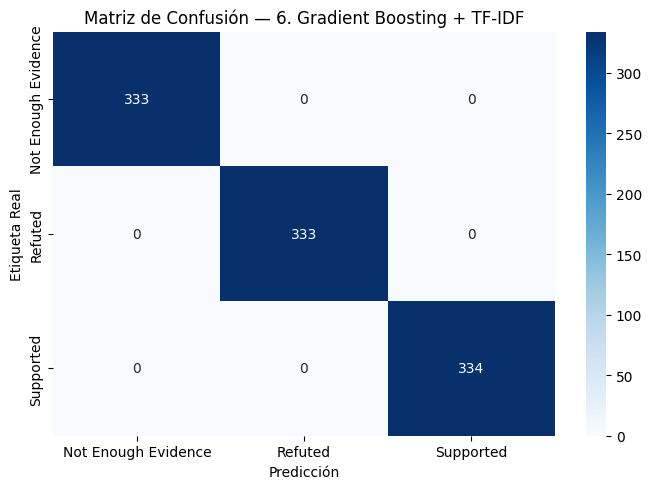

In [13]:
t0 = time.time()
gb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])
gb_pipeline.fit(X_train_raw, y_train)
y_pred_gb = gb_pipeline.predict(X_test_raw)
t1 = time.time()

evaluate_model('6. Gradient Boosting + TF-IDF', y_test, y_pred_gb, t1 - t0)
plot_confusion_matrix('6. Gradient Boosting + TF-IDF', y_test, y_pred_gb)

## 6. Preparación para modelos de Deep Learning

In [14]:
MAX_WORDS = 20000
MAX_LEN   = 50
EMBED_DIM = 128

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(list(X_train_raw) + list(X_val_raw) + list(X_test_raw))

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = encode(X_train_raw)
X_val_seq   = encode(X_val_raw)
X_test_seq  = encode(X_test_raw)

num_classes = len(le.classes_)

print(f'Vocabulario efectivo: {MAX_WORDS:,}')
print(f'Longitud de secuencia: {MAX_LEN}')
print(f'Número de clases: {num_classes}')
print(f'X_train_seq shape: {X_train_seq.shape}')

Vocabulario efectivo: 20,000
Longitud de secuencia: 50
Número de clases: 3
X_train_seq shape: (8000, 50)


In [15]:
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

def train_dl_model(model, name, epochs=30, batch_size=64):
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    model.summary()

    t0 = time.time()
    history = model.fit(
        X_train_seq, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val_seq, y_val),
        callbacks=get_callbacks(),
        verbose=1
    )
    t1 = time.time()

    y_pred_probs = model.predict(X_test_seq)
    y_pred = np.argmax(y_pred_probs, axis=1)

    evaluate_model(name, y_test, y_pred, t1 - t0)
    plot_confusion_matrix(name, y_test, y_pred)
    plot_training_history(history, name)

    return history, y_pred


def plot_training_history(history, name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(history.history['loss'],     label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'Loss — {name}')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True)

    ax2.plot(history.history['accuracy'],     label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title(f'Accuracy — {name}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.show()

## 7. Modelo 7 — LSTM con Embedding aprendido

**Arquitectura:**
- `Embedding(20000, 128)`: Vectores aprendidos durante el entrenamiento (equivalente al modelo del notebook principal).
- `LSTM(64)`: Captura dependencias secuenciales.
- `Dense(3, softmax)`: Clasificación final.

Este modelo es el **baseline de Deep Learning**.

I0000 00:00:1776640988.365546      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776640988.371745      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.3379 - loss: 1.1003 - val_accuracy: 0.3330 - val_loss: 1.0955 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.5751 - loss: 0.6699 - val_accuracy: 0.6670 - val_loss: 0.4623 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - accuracy: 0.6658 - loss: 0.4657 - val_accuracy: 0.6665 - val_loss: 0.4628 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.6628 - loss: 0.4694 - val_accuracy: 0.6670 - val_loss: 0.4620 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.6739 - loss: 0.4633 - val_accuracy: 0.6670 - val_loss: 0.4622 - learning_rate: 0.0010
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - accuracy: 0.6635 - loss: 0.4692 - val_accuracy: 0.6665 - val_loss: 0.4625 - learning_rate: 0.0010
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.658

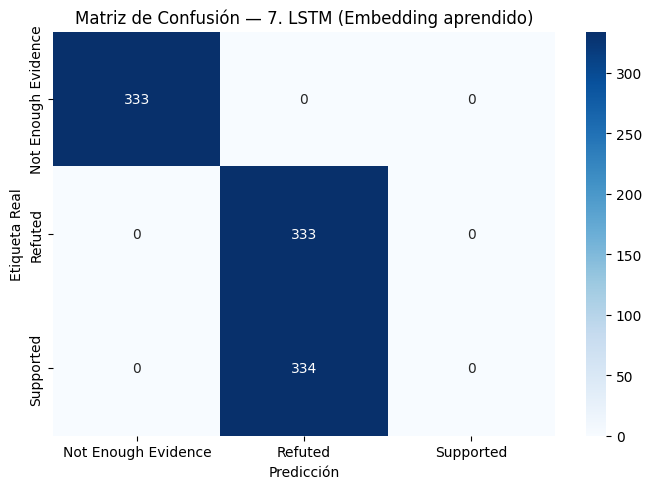

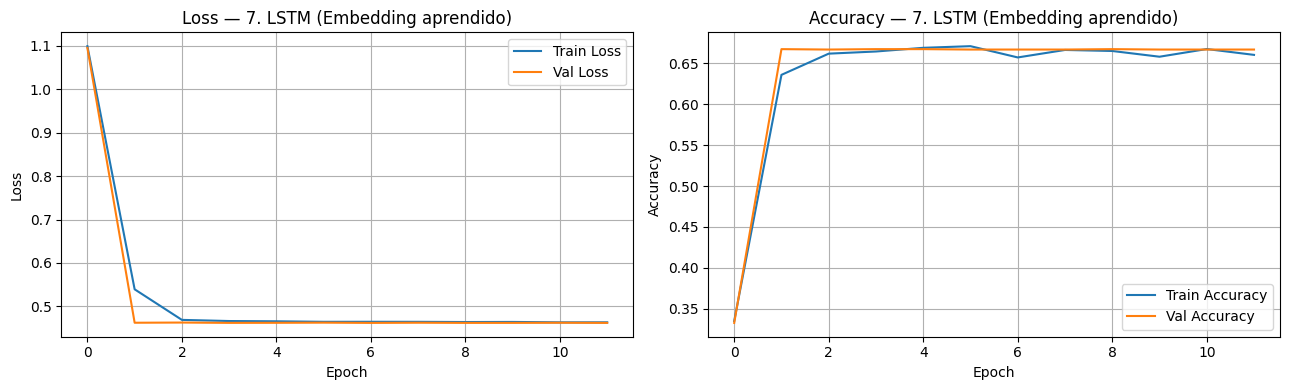

In [16]:
def build_lstm():
    return Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),
        LSTM(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

lstm_model = build_lstm()
hist_lstm, y_pred_lstm = train_dl_model(lstm_model, '7. LSTM (Embedding aprendido)')

## 8. Modelo 8 — BiLSTM con Embedding aprendido

**Arquitectura:**
- `Embedding(20000, 128)`: Vectores aprendidos.
- `Bidirectional(LSTM(64))`: Procesa la secuencia en **ambas direcciones**, capturando mejor el contexto completo de la afirmación.
- `Dense(3, softmax)`: Clasificación final.

Útil para detectar negaciones como "no existe evidencia" donde el sentido depende del contexto global.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - accuracy: 0.7730 - loss: 0.5966 - val_accuracy: 1.0000 - val_loss: 2.7320e-05 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.9993 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 1.6802e-06 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.9994 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 1.8136e-06 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 1.0000 - loss: 0.0011
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 2.1189e-07 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - accuracy: 1.0000 - loss: 7.1002e-04 - val_accuracy: 1.0000 - val_loss: 7.1228e-08 - learning_rate: 5.0000e-04
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 

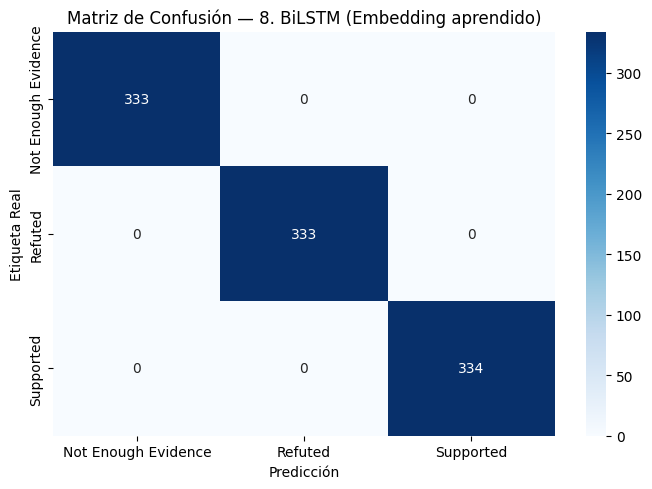

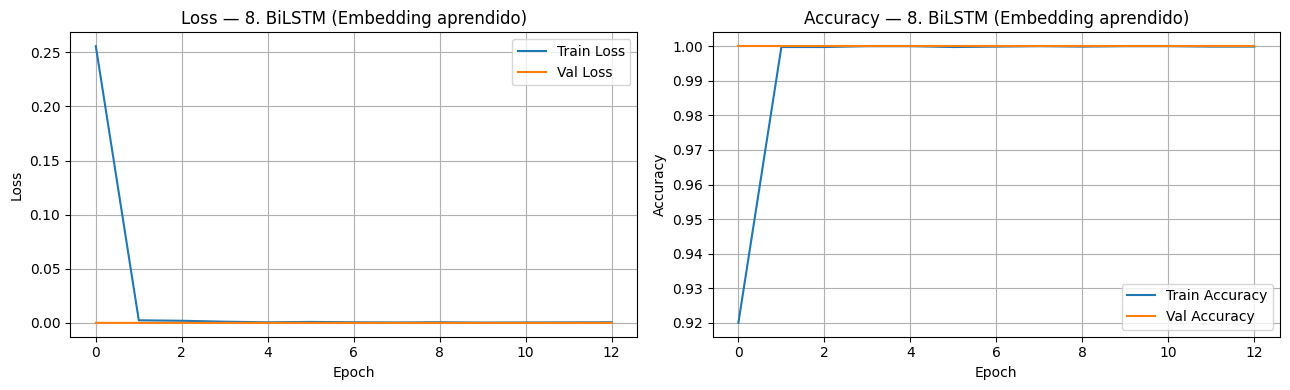

In [17]:
def build_bilstm():
    return Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

bilstm_model = build_bilstm()
hist_bilstm, y_pred_bilstm = train_dl_model(bilstm_model, '8. BiLSTM (Embedding aprendido)')

## 9. Comparación final de todos los modelos

In [18]:
df_results = pd.DataFrame(results).T.reset_index()
df_results.columns = ['Modelo', 'Accuracy', 'F1 Macro', 'F1 Weighted', 'Training Time (s)']
df_results = df_results.sort_values('F1 Macro', ascending=False).reset_index(drop=True)

print('\n' + '='*80)
print('TABLA COMPARATIVA DE MODELOS — SCVD-11K Fact-Checking')
print('='*80)
print(df_results.to_string(index=False))
print('='*80)


TABLA COMPARATIVA DE MODELOS — SCVD-11K Fact-Checking
                         Modelo  Accuracy  F1 Macro  F1 Weighted  Training Time (s)
2. Logistic Regression + TF-IDF     1.000    1.0000       1.0000               0.16
        3. Naive Bayes + TF-IDF     1.000    1.0000       1.0000               0.10
         4. SVM Lineal + TF-IDF     1.000    1.0000       1.0000               0.35
      5. Random Forest + TF-IDF     1.000    1.0000       1.0000               0.71
8. BiLSTM (Embedding aprendido)     1.000    1.0000       1.0000             265.38
  6. Gradient Boosting + TF-IDF     1.000    1.0000       1.0000               3.42
  7. LSTM (Embedding aprendido)     0.666    0.5553       0.5548             162.69
            1. Dummy Classifier     0.333    0.1665       0.1664               0.00


## 10. Predicción sobre texto libre

Función para probar cualquier afirmación científica con todos los modelos entrenados.
Cambia el texto en `my_claim` para probarlo.

In [19]:
def predict_claim(text, show_probabilities=True):
    """
    Clasifica una afirmación científica con todos los modelos entrenados.

    Parámetros:
        text (str): Afirmación científica a clasificar.
        show_probabilities (bool): Muestra las probabilidades de los modelos DL.
    """
    # --- 1. Limpiar el texto ---
    import re
    text_clean = re.sub(r'\(Statement ID \d+\)$', '', text)
    text_clean = re.sub(r'\[.*?\]', '', text_clean)
    text_clean = re.sub(r'\n+', ' ', text_clean)
    text_clean = re.sub(r'[^a-zA-Z\s]', ' ', text_clean)
    text_clean = re.sub(r'\s+', ' ', text_clean).strip().lower()

    print('=' * 60)
    print(f'Afirmación original: {text}')
    print(f'Texto limpio:        {text_clean}')
    print('=' * 60)

    # --- 2. Predicciones ML Clásico ---
    ml_models = {
        '2. Logistic Regression': lr_pipeline,
        '3. Naive Bayes':         nb_pipeline,
        '4. SVM Lineal':          svm_pipeline,
        '5. Random Forest':       rf_pipeline,
        '6. Gradient Boosting':   gb_pipeline,
    }

    print('\n📊 Modelos ML Clásico (TF-IDF):')
    for name, model in ml_models.items():
        pred_idx = model.predict([text_clean])[0]
        pred_label = le.inverse_transform([pred_idx])[0]
        print(f'  {name:30s} → {pred_label}')

    # --- 3. Preparar secuencia para modelos DL ---
    seq    = tokenizer.texts_to_sequences([text_clean])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    dl_models = {
        '7. LSTM':           lstm_model,
        '8. BiLSTM':         bilstm_model,
    }

    print('\n🧠 Modelos Deep Learning:')
    for name, model in dl_models.items():
        probs      = model.predict(padded, verbose=0)[0]
        pred_idx   = np.argmax(probs)
        pred_label = le.classes_[pred_idx]
        confidence = probs[pred_idx] * 100

        print(f'  {name:30s} → {pred_label}  (confianza: {confidence:.1f}%)')

        if show_probabilities:
            for cls, prob in zip(le.classes_, probs):
                bar = '█' * int(prob * 20)
                print(f'      {cls:22s}: {prob:.4f}  {bar}')

    print('=' * 60)

In [20]:
# ── Cambia este texto para probar cualquier afirmación ──
my_claim = "If you're reading the New York Times, you aren't getting the truth about Iran"

predict_claim(my_claim)

Afirmación original: If you're reading the New York Times, you aren't getting the truth about Iran
Texto limpio:        if you re reading the new york times you aren t getting the truth about iran

📊 Modelos ML Clásico (TF-IDF):
  2. Logistic Regression         → Refuted
  3. Naive Bayes                 → Refuted
  4. SVM Lineal                  → Refuted
  5. Random Forest               → Refuted
  6. Gradient Boosting           → Refuted

🧠 Modelos Deep Learning:
  7. LSTM                        → Refuted  (confianza: 50.1%)
      Not Enough Evidence   : 0.0000  
      Refuted               : 0.5008  ██████████
      Supported             : 0.4992  █████████
  8. BiLSTM                      → Supported  (confianza: 99.4%)
      Not Enough Evidence   : 0.0039  
      Refuted               : 0.0025  
      Supported             : 0.9936  ███████████████████


In [21]:
# Prueba con múltiples afirmaciones de ejemplo
examples = [
    "The Earth revolves around the Sun.",
    "Climate change is a hoax created by scientists.",
    "A new vaccine candidate may reduce infection rates.",
    "Antibiotics cure viral infections.",
    "Dark matter might interact weakly with normal matter.",
]

for claim in examples:
    predict_claim(claim, show_probabilities=False)
    print()

Afirmación original: The Earth revolves around the Sun.
Texto limpio:        the earth revolves around the sun

📊 Modelos ML Clásico (TF-IDF):
  2. Logistic Regression         → Supported
  3. Naive Bayes                 → Supported
  4. SVM Lineal                  → Supported
  5. Random Forest               → Supported
  6. Gradient Boosting           → Supported

🧠 Modelos Deep Learning:
  7. LSTM                        → Refuted  (confianza: 50.1%)
  8. BiLSTM                      → Supported  (confianza: 100.0%)

Afirmación original: Climate change is a hoax created by scientists.
Texto limpio:        climate change is a hoax created by scientists

📊 Modelos ML Clásico (TF-IDF):
  2. Logistic Regression         → Refuted
  3. Naive Bayes                 → Refuted
  4. SVM Lineal                  → Refuted
  5. Random Forest               → Refuted
  6. Gradient Boosting           → Refuted

🧠 Modelos Deep Learning:
  7. LSTM                        → Refuted  (confianza: 50.1%)
  8